# Computer Vision Assignment 2
## Chest X-Ray Image Classification using TensorFlow and Keras

**Student Name:** Joel George  
**Student Number:** B00118121  
**Module:** Computer Vision  

### Goal
Maximise classification accuracy, precision, and recall on the chest X-ray dataset.

In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
# Path to the training folder
# Change this if your folder is in a different place
train_dir = r"C:\Assignment 2 - B00118121\chest_xray\chest_xray\train"

# Path to the test folder
test_dir  = r"C:\Assignment 2 - B00118121\chest_xray\chest_xray\test"

# Resize all images to 128x128 before training
# This makes the input size fixed for the neural network
img_height = 128
img_width = 128

# Number of images processed at once during training
batch_size = 16

# Seed makes the dataset split repeatable
# This means you get the same training/validation split each time
seed = 123

# Number of training passes over the full dataset
epochs = 15

## 1. Dataset Loading and Preprocessing

In this section, the chest X-ray dataset is loaded from the train and test folders.  
A validation split is created from the training set so that the model can be monitored during training.

The dataset contains three classes:

- BACTERIAL
- NORMAL
- VIRAL

In [4]:
# Create the training dataset from the train folder
# validation_split=0.2 means 20% of the training folder will be used for validation
# subset="training" means this dataset is the 80% training part
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="int"   # labels are integers like 0, 1, 2
)

# Create the validation dataset from the same train folder
# subset="validation" means this is the remaining 20%
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="int"
)

# Create the separate test dataset from the test folder
# shuffle=False is important so evaluation order stays fixed
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    label_mode="int"
)

# Save the class names from the folder names
# For your dataset this should be something like:
# ['BACTERIAL', 'NORMAL', 'VIRAL']
class_names = train_ds.class_names

# Print class names to check they loaded correctly
print("Classes:", class_names)

Found 5419 files belonging to 3 classes.
Using 4336 files for training.
Found 5419 files belonging to 3 classes.
Using 1083 files for validation.
Found 437 files belonging to 3 classes.
Classes: ['BACTERIAL', 'NORMAL', 'VIRAL']


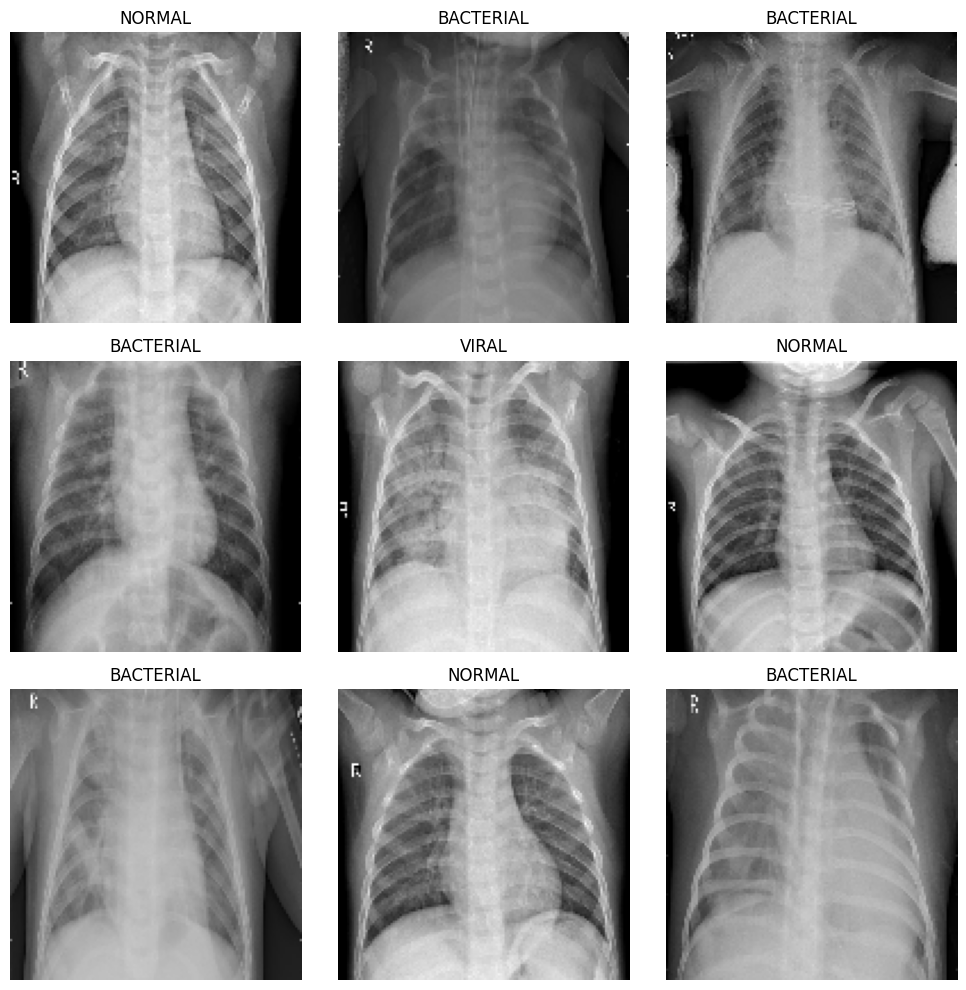

In [5]:
# Create a figure window big enough to show 9 images
plt.figure(figsize=(10, 10))

# Take just one batch from the training dataset
for images, labels in train_ds.take(1):
    
    # Loop through the first 9 images in the batch
    for i in range(9):
        # Create a 3x3 grid of plots
        ax = plt.subplot(3, 3, i + 1)
        
        # Show the image
        plt.imshow(images[i].numpy().astype("uint8"))
        
        # Show the class name as the title
        plt.title(class_names[labels[i].numpy()])
        
        # Hide axis numbers for cleaner display
        plt.axis("off")

# Make spacing look better
plt.tight_layout()

# Display the images
plt.show()

## 2. Dataset Exploration

This section displays sample images from the dataset and checks the class distribution.

This is important because class imbalance can affect model performance and cause the model to favour the majority class.

Training set class distribution:
{'BACTERIAL': 2087, 'NORMAL': 1165, 'VIRAL': 1084}


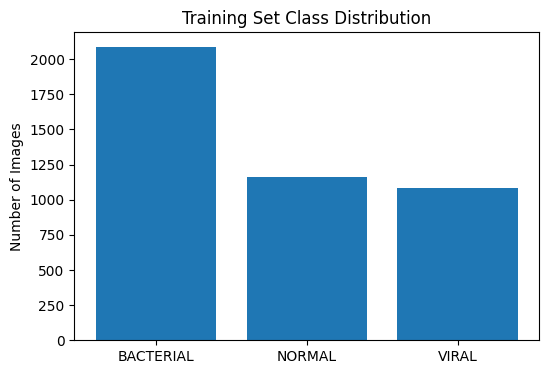

In [6]:
# Create a dictionary to count how many images are in each class
# Start all class counts at 0
train_counts = {name: 0 for name in class_names}

# Go through every label in the training dataset one by one
for _, labels in train_ds.unbatch():
    # Convert the label number to the class name and increase its count
    train_counts[class_names[int(labels.numpy())]] += 1

# Print the class counts
print("Training set class distribution:")
print(train_counts)

# Plot the class counts as a bar chart
plt.figure(figsize=(6,4))
plt.bar(train_counts.keys(), train_counts.values())
plt.title("Training Set Class Distribution")
plt.ylabel("Number of Images")
plt.show()

In [7]:
# Create an empty list to store all training labels
y_train_all = []

# Go through every training label in the dataset
for _, labels in train_ds.unbatch():
    # Add each label as a normal integer
    y_train_all.append(int(labels.numpy()))

# Convert the list to a NumPy array
y_train_all = np.array(y_train_all)

# Compute balanced class weights
# This gives bigger weights to smaller classes
# So mistakes on under-represented classes matter more during training
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_all),
    y=y_train_all
)

# Turn the array into a dictionary format Keras expects
# Example: {0: 1.2, 1: 0.8, 2: 1.5}
class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}

# Print the weights
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.6925411276153969), 1: np.float64(1.240629470672389), 2: np.float64(1.3333333333333333)}


## 3. Handling Class Imbalance and Data Augmentation

Class weights are calculated to reduce bias toward larger classes.

Data augmentation is also applied to the training images.  
This creates slightly modified versions of images during training, which can improve generalisation and reduce overfitting.

In [12]:
# Data augmentation creates slightly changed versions of training images
# This helps the model generalise better and reduce overfitting
data_augmentation = keras.Sequential([
    
    # Randomly flip images left-right
    layers.RandomFlip("horizontal"),
    
    # Slight random rotation
    layers.RandomRotation(0.05),
    
    # Slight random zoom in/out
    layers.RandomZoom(0.1),
    
    # Slight random movement up/down and left/right
    layers.RandomTranslation(0.05, 0.05),
])

In [13]:
# This function builds our CNN model
def make_cnn_model():
    model = models.Sequential([
        
        # Input layer: images are 128x128 with 3 colour channels
        layers.Input(shape=(img_height, img_width, 3)),
        
        # Apply data augmentation only during training
        data_augmentation,
        
        # Scale pixel values from 0-255 down to 0-1
        layers.Rescaling(1./255),

        # First convolution block
        # Learns simple features like edges and textures
        layers.Conv2D(32, 3, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        # Second convolution block
        # Learns more complex patterns
        layers.Conv2D(64, 3, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        # Third convolution block
        # Learns even higher-level image features
        layers.Conv2D(128, 3, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        # GlobalAveragePooling2D replaces Flatten
        # It reduces the number of parameters and can reduce overfitting
        layers.GlobalAveragePooling2D(),

        # Dense layer helps combine learned features for classification
        layers.Dense(128, activation='relu'),
        
        # Dropout randomly turns off some neurons during training
        # This helps prevent overfitting
        layers.Dropout(0.3),

        # Final output layer
        # Number of outputs = number of classes
        # Softmax gives class probabilities
        layers.Dense(len(class_names), activation='softmax')
    ])

    # Compile the model
    # Adam = optimiser
    # sparse_categorical_crossentropy = correct loss for integer class labels
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Build the model
cnn_model = make_cnn_model()

# Show model structure
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,043 (433.76 KB)

 Trainable params: 110,595 (432.01 KB)

 Non-trainable params: 448 (1.75 KB)

## 4. Improved CNN Model

An improved convolutional neural network (CNN) is built using:

- Conv2D layers for feature extraction
- Batch Normalization for more stable training
- MaxPooling layers for downsampling
- GlobalAveragePooling2D instead of Flatten to reduce overfitting
- Dropout for regularisation

This model is trained first as a custom baseline model.

In [14]:
# EarlyStopping watches validation loss
# If it does not improve for 5 epochs, training stops early
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# ModelCheckpoint saves the best model file during training
checkpoint = ModelCheckpoint(
    "best_cnn_model.keras",
    save_best_only=True
)

# Record start time before training
start_time = time.time()

# Train the CNN model
cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,                  # try up to 20 epochs
    callbacks=[early_stop, checkpoint],
    class_weight=class_weights  # use class weights to help imbalance
)

# Calculate total training time
cnn_train_time = time.time() - start_time

# Print training time
print(f"CNN training time: {cnn_train_time:.2f} seconds")

Epoch 1/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 121s 409ms/step - accuracy: 0.6169 - loss: 0.8320 - val_accuracy: 0.2622 - val_loss: 2.4328
Epoch 2/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 114s 419ms/step - accuracy: 0.6778 - loss: 0.7334 - val_accuracy: 0.3093 - val_loss: 1.5620
Epoch 3/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 102s 374ms/step - accuracy: 0.6845 - loss: 0.7109 - val_accuracy: 0.2844 - val_loss: 3.2550
Epoch 4/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 109s 401ms/step - accuracy: 0.7025 - loss: 0.6647 - val_accuracy: 0.2733 - val_loss: 9.2427
Epoch 5/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 102s 374ms/step - accuracy: 0.7039 - loss: 0.6677 - val_accuracy: 0.2779 - val_loss: 9.6188
Epoch 6/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 101s 370ms/step - accuracy: 0.7209 - loss: 0.6397 - val_accuracy: 0.5642 - val_loss: 0.8265
Epoch 7/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 108s 398ms/step - accuracy: 0.7410 - loss: 0.6065 - val_accuracy: 0.6777 - val_loss: 0.7519
Epoch 8/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 100s 367ms/step - accuracy: 0.7394 -

## 5. CNN Training and Evaluation

The improved CNN is trained using:

- EarlyStopping to stop training when validation loss stops improving
- ModelCheckpoint to save the best model
- Class weights to handle imbalance

The model is then evaluated using:

- Test accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

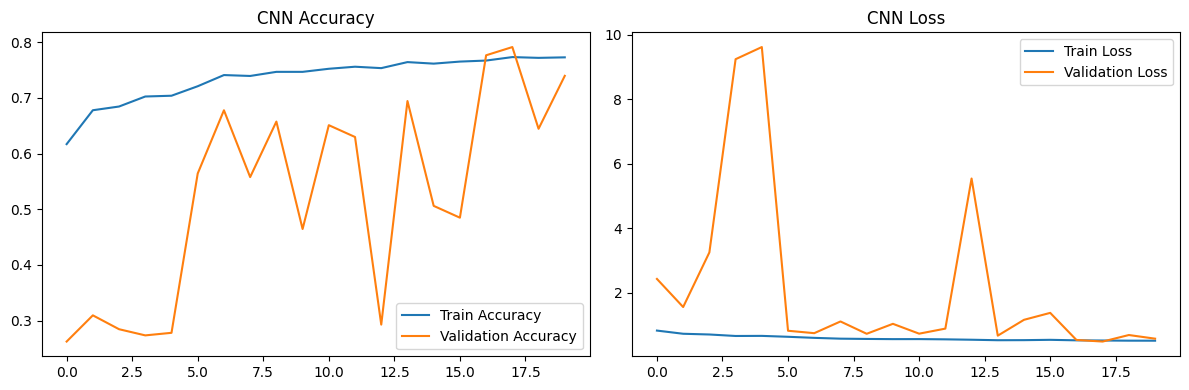

In [15]:
# Create a wide figure for two graphs side by side
plt.figure(figsize=(12,4))

# ---- Accuracy graph ----
plt.subplot(1,2,1)

# Plot training accuracy
plt.plot(cnn_history.history['accuracy'], label='Train Accuracy')

# Plot validation accuracy
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')

# Add title and legend
plt.title('CNN Accuracy')
plt.legend()

# ---- Loss graph ----
plt.subplot(1,2,2)

# Plot training loss
plt.plot(cnn_history.history['loss'], label='Train Loss')

# Plot validation loss
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')

# Add title and legend
plt.title('CNN Loss')
plt.legend()

# Make spacing look better
plt.tight_layout()

# Show the graphs
plt.show()

In [16]:
# Evaluate the trained CNN on the separate test set
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(test_ds)

# Print final test accuracy
print("CNN Test Accuracy:", cnn_test_acc)

28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.7849 - loss: 0.4905
CNN Test Accuracy: 0.7848970293998718


=== CNN Classification Report ===
              precision    recall  f1-score   support

   BACTERIAL       0.75      0.85      0.79       184
      NORMAL       0.85      0.94      0.89       122
       VIRAL       0.77      0.55      0.64       131

    accuracy                           0.78       437
   macro avg       0.79      0.78      0.78       437
weighted avg       0.78      0.78      0.78       437



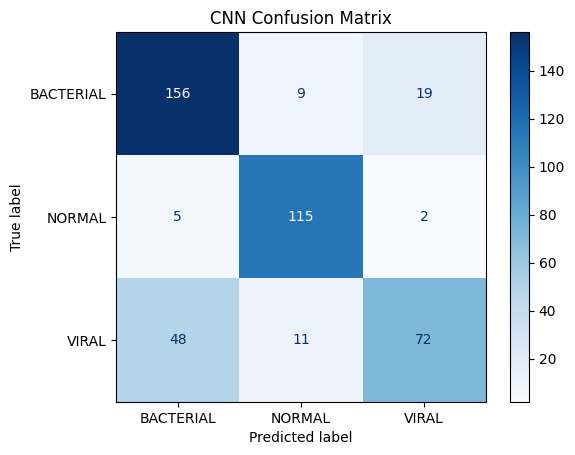

In [17]:
# Store true labels and predicted labels
y_true = []
y_pred = []

# Go through every batch in the test dataset
for images, labels in test_ds:
    
    # Get predicted probabilities from the model
    preds = cnn_model.predict(images, verbose=0)
    
    # Add the real labels to the list
    y_true.extend(labels.numpy())
    
    # Convert predicted probabilities to class indexes
    y_pred.extend(np.argmax(preds, axis=1))

# Print the classification report
# This includes precision, recall and F1-score for each class
print("=== CNN Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_names))

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display it nicely
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")

# Add title
plt.title("CNN Confusion Matrix")

# Show it
plt.show()

In [18]:
# This function builds a transfer learning model
def make_transfer_model():
    
    # Load MobileNetV2 without its original final classifier
    # weights='imagenet' means it starts with knowledge learned from a huge dataset
    base_model = MobileNetV2(
        input_shape=(img_height, img_width, 3),
        include_top=False,
        weights='imagenet'
    )
    
    # Freeze the base model so its pre-trained weights do not change at first
    base_model.trainable = False

    # Define a new input layer
    inputs = keras.Input(shape=(img_height, img_width, 3))
    
    # Apply data augmentation
    x = data_augmentation(inputs)
    
    # Rescale image pixels to 0-1
    x = layers.Rescaling(1./255)(x)
    
    # Pass images through the pre-trained MobileNetV2
    x = base_model(x, training=False)
    
    # Reduce feature maps to one vector per image
    x = layers.GlobalAveragePooling2D()(x)
    
    # Dropout for regularisation
    x = layers.Dropout(0.3)(x)
    
    # New classifier for our 3 chest X-ray classes
    outputs = layers.Dense(len(class_names), activation='softmax')(x)

    # Build the final model
    model = keras.Model(inputs, outputs)

    # Compile the model
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Build the transfer learning model
transfer_model = make_transfer_model()

# Show model structure
transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
# Early stopping for transfer learning model
early_stop_tl = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Save the best transfer model
checkpoint_tl = ModelCheckpoint(
    "best_transfer_model.keras",
    save_best_only=True
)

# Start timer
start_time = time.time()

# Train transfer learning model
transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop_tl, checkpoint_tl],
    class_weight=class_weights
)

# Measure total training time
transfer_train_time = time.time() - start_time

# Print training time
print(f"Transfer model training time: {transfer_train_time:.2f} seconds")

Epoch 1/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 64s 214ms/step - accuracy: 0.6204 - loss: 0.8432 - val_accuracy: 0.6547 - val_loss: 0.8455
Epoch 2/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 54s 199ms/step - accuracy: 0.6817 - loss: 0.7045 - val_accuracy: 0.6039 - val_loss: 0.9100
Epoch 3/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 55s 202ms/step - accuracy: 0.7032 - loss: 0.6628 - val_accuracy: 0.6741 - val_loss: 0.7178
Epoch 4/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 50s 185ms/step - accuracy: 0.7161 - loss: 0.6281 - val_accuracy: 0.7008 - val_loss: 0.6876
Epoch 5/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 58s 213ms/step - accuracy: 0.7115 - loss: 0.6357 - val_accuracy: 0.6380 - val_loss: 0.7851
Epoch 6/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 49s 179ms/step - accuracy: 0.7223 - loss: 0.6204 - val_accuracy: 0.6260 - val_loss: 0.7880
Epoch 7/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 52s 192ms/step - accuracy: 0.7216 - loss: 0.6145 - val_accuracy: 0.7128 - val_loss: 0.6765
Epoch 8/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 50s 186ms/step - accuracy: 0.7272 - loss: 0

## 6. Transfer Learning with MobileNetV2

Transfer learning is used to improve performance by starting with a pre-trained MobileNetV2 model.

The convolutional base is frozen initially, and a new classifier is added for the chest X-ray classes.

This approach often performs better than training a CNN from scratch, especially when the dataset is not extremely large.

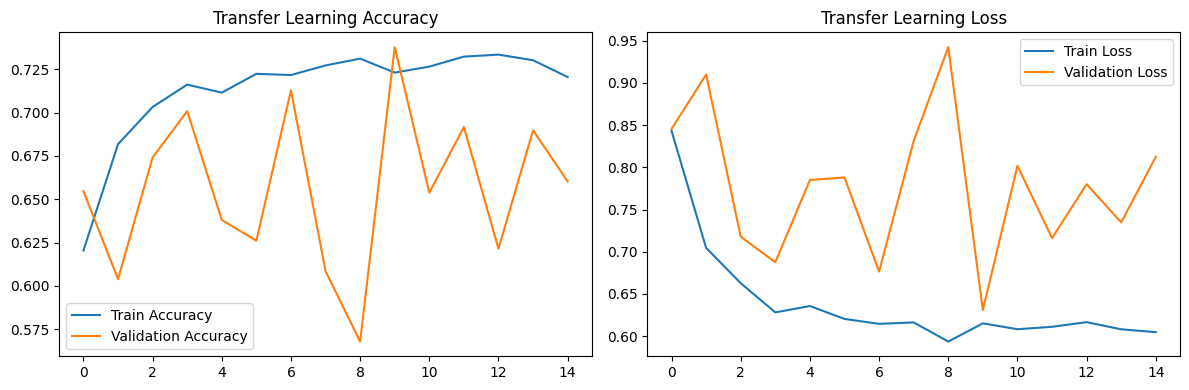

In [20]:
# Create figure for two graphs
plt.figure(figsize=(12,4))

# ---- Accuracy graph ----
plt.subplot(1,2,1)
plt.plot(transfer_history.history['accuracy'], label='Train Accuracy')
plt.plot(transfer_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.legend()

# ---- Loss graph ----
plt.subplot(1,2,2)
plt.plot(transfer_history.history['loss'], label='Train Loss')
plt.plot(transfer_history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 7. Transfer Learning Training and Evaluation

The transfer learning model is trained and evaluated in the same way as the custom CNN.

Its performance is compared using:

- Training time
- Test accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

In [21]:
# Evaluate transfer model on the test set
transfer_test_loss, transfer_test_acc = transfer_model.evaluate(test_ds)

# Print test accuracy
print("Transfer Learning Test Accuracy:", transfer_test_acc)

28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step - accuracy: 0.7346 - loss: 0.6289
Transfer Learning Test Accuracy: 0.7345537543296814


=== Transfer Learning Classification Report ===
              precision    recall  f1-score   support

   BACTERIAL       0.75      0.70      0.72       184
      NORMAL       0.75      0.96      0.84       122
       VIRAL       0.68      0.58      0.63       131

    accuracy                           0.73       437
   macro avg       0.73      0.74      0.73       437
weighted avg       0.73      0.73      0.73       437



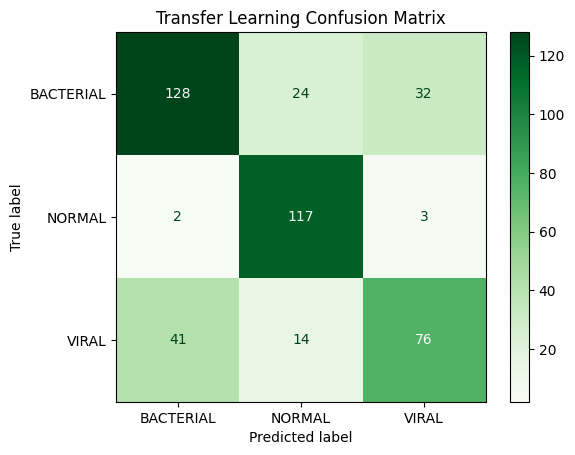

In [22]:
# Store true labels and predictions for transfer model
y_true_tl = []
y_pred_tl = []

# Loop through the test dataset
for images, labels in test_ds:
    
    # Predict class probabilities
    preds = transfer_model.predict(images, verbose=0)
    
    # Save true labels
    y_true_tl.extend(labels.numpy())
    
    # Save predicted class indexes
    y_pred_tl.extend(np.argmax(preds, axis=1))

# Print classification report
print("=== Transfer Learning Classification Report ===")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

# Create confusion matrix
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tl, display_labels=class_names)
disp.plot(cmap="Greens")
plt.title("Transfer Learning Confusion Matrix")
plt.show()

## 9. Final Model Comparison

The final table below compares the two main approaches used in this notebook:

- Improved CNN
- Transfer Learning (MobileNetV2)

The comparison includes:

- Test accuracy
- Training time

This helps identify which approach performed best overall.

In [23]:
# Create a comparison table of the main models
results = pd.DataFrame({
    "Model": ["Improved CNN", "Transfer Learning"],
    "Test Accuracy": [cnn_test_acc, transfer_test_acc],
    "Training Time (s)": [cnn_train_time, transfer_train_time]
})

# Show the table
results

,Model,Test Accuracy,Training Time (s)
0,Improved CNN,0.784897,2007.872700
1,Transfer Learning,0.734554,791.398798
